In [8]:
import kagglehub
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [2]:
path = kagglehub.dataset_download("dgomonov/new-york-city-airbnb-open-data")
print("Path to dataset files:", path)

for file in os.listdir(path):
    if file.endswith(".csv"):
        csv_path = os.path.join(path, file)
        break

df = pd.read_csv(csv_path)
df.head()

100%|██████████| 2.44M/2.44M [00:00<00:00, 96.6MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/dgomonov/new-york-city-airbnb-open-data/versions/3


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## Clean Data

In [3]:
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df[(df['price'] > 0) & (df['price'] <= 1000)]

df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')

df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

print(df.head())
print(f"Dataset shape after cleaning: {df.shape}")

     id                                              name  host_id  \
0  2539                Clean & quiet apt home by the park     2787   
1  2595                             Skylit Midtown Castle     2845   
2  3647               THE VILLAGE OF HARLEM....NEW YORK !     4632   
3  3831                   Cozy Entire Floor of Brownstone     4869   
4  5022  Entire Apt: Spacious Studio/Loft by central park     7192   

     host_name neighbourhood_group neighbourhood  latitude  longitude  \
0         John            Brooklyn    Kensington  40.64749  -73.97237   
1     Jennifer           Manhattan       Midtown  40.75362  -73.98377   
2    Elisabeth           Manhattan        Harlem  40.80902  -73.94190   
3  LisaRoxanne            Brooklyn  Clinton Hill  40.68514  -73.95976   
4        Laura           Manhattan   East Harlem  40.79851  -73.94399   

         room_type  price  minimum_nights  number_of_reviews last_review  \
0     Private room    149               1                  9  20

## Feature Engineering

In [5]:
cat_cols = ['room_type', 'neighbourhood_group', 'neighbourhood']
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

df_encoded['last_review_year'] = df_encoded['last_review'].dt.year.fillna(0)
df_encoded['last_review_month'] = df_encoded['last_review'].dt.month.fillna(0)

df_encoded = df_encoded.drop(['id', 'name', 'host_id', 'host_name', 'last_review'], axis=1)

df_encoded

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,room_type_Private room,room_type_Shared room,...,neighbourhood_Williamsbridge,neighbourhood_Williamsburg,neighbourhood_Willowbrook,neighbourhood_Windsor Terrace,neighbourhood_Woodhaven,neighbourhood_Woodlawn,neighbourhood_Woodrow,neighbourhood_Woodside,last_review_year,last_review_month
0,40.64749,-73.97237,149,1,9,0.21,6,365,True,False,...,False,False,False,False,False,False,False,False,2018.0,10.0
1,40.75362,-73.98377,225,1,45,0.38,2,355,False,False,...,False,False,False,False,False,False,False,False,2019.0,5.0
2,40.80902,-73.94190,150,3,0,0.00,1,365,True,False,...,False,False,False,False,False,False,False,False,0.0,0.0
3,40.68514,-73.95976,89,1,270,4.64,1,194,False,False,...,False,False,False,False,False,False,False,False,2019.0,7.0
4,40.79851,-73.94399,80,10,9,0.10,1,0,False,False,...,False,False,False,False,False,False,False,False,2018.0,11.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,40.67853,-73.94995,70,2,0,0.00,2,9,True,False,...,False,False,False,False,False,False,False,False,0.0,0.0
48891,40.70184,-73.93317,40,4,0,0.00,2,36,True,False,...,False,False,False,False,False,False,False,False,0.0,0.0
48892,40.81475,-73.94867,115,10,0,0.00,1,27,False,False,...,False,False,False,False,False,False,False,False,0.0,0.0
48893,40.75751,-73.99112,55,1,0,0.00,6,2,False,True,...,False,False,False,False,False,False,False,False,0.0,0.0


In [6]:
# Features and target
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

Training set: (38916, 235), Test set: (9729, 235)


## Train Model (Random Forest)

In [7]:
model = RandomForestRegressor(n_estimators=200, max_depth=20, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.2f}")

RMSE: 86.22
MAE: 48.57
R2 Score: 0.47


## Feature Importance

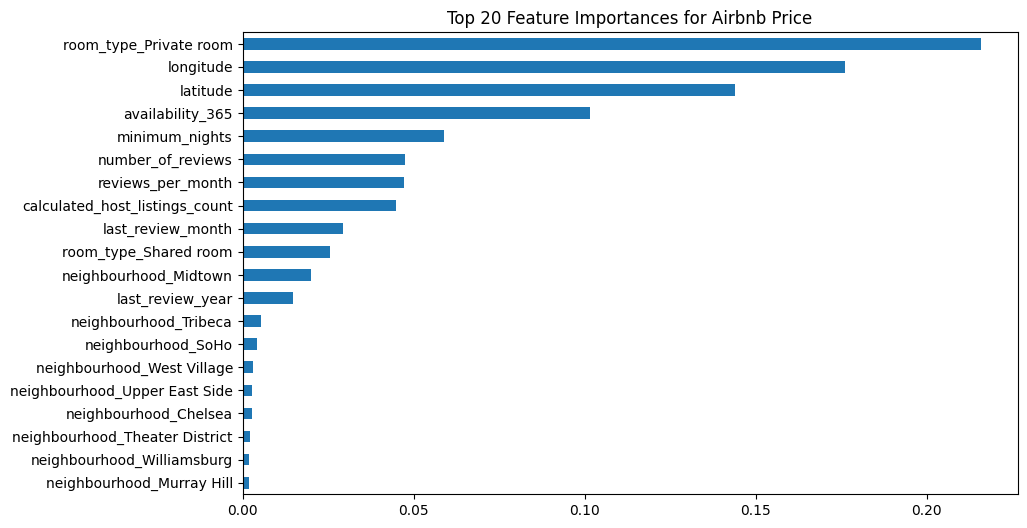

In [10]:
importances = model.feature_importances_
features = X_train.columns
feat_importances = pd.Series(importances, index=features).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_importances[:20].plot(kind='barh')
plt.title("Top 20 Feature Importances for Airbnb Price")
plt.gca().invert_yaxis()
plt.show()

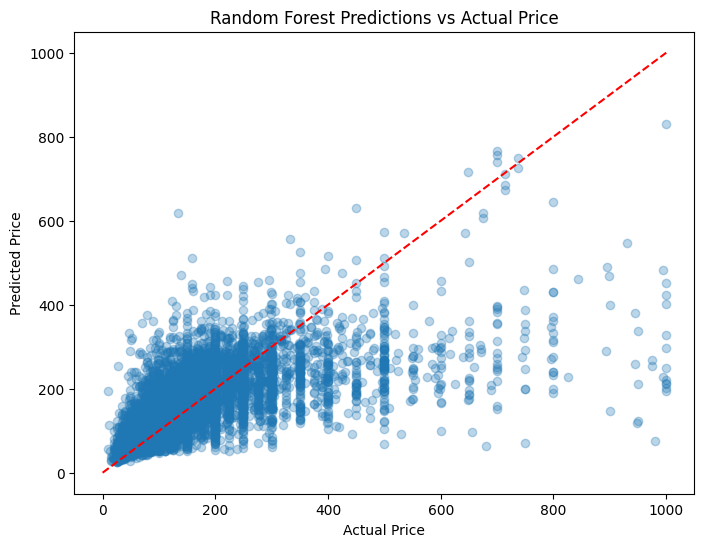

In [12]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest Predictions vs Actual Price")
plt.plot([0,1000],[0,1000], 'r--')
plt.show()